# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Cargar los datasets
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [3]:
# Mostrar primeras filas de cada DataFrame
print("=== PLANS ===")
print(plans.head())

=== PLANS ===
  plan_name  messages_included  gb_per_month  minutes_included  \
0    Basico                100             5               100   
1   Premium                500            20               600   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute  
0               12         1.2             0.08            0.10  
1               25         1.0             0.05            0.07  


In [4]:
print("\n=== USERS ===")
print(users.head())


=== USERS ===
   user_id first_name last_name  age      city                       reg_date  \
0    10000     Carlos    Garcia   38  Medellín  2022-01-01 00:00:00.000000000   
1    10001      Mateo    Torres   53         ?  2022-01-01 06:34:17.914478619   
2    10002      Sofia   Ramirez   57      CDMX  2022-01-01 13:08:35.828957239   
3    10003      Mateo   Ramirez   69    Bogotá  2022-01-01 19:42:53.743435858   
4    10004      Mateo    Torres   63       GDL  2022-01-02 02:17:11.657914478   

      plan churn_date  
0   Basico        NaN  
1   Basico        NaN  
2   Basico        NaN  
3  Premium        NaN  
4   Basico        NaN  


In [5]:
print("\n=== USAGE ===")
print(usage.head())


=== USAGE ===
   id  user_id  type                           date  duration  length
0   1    10332  call  2024-01-01 00:00:00.000000000      0.09     NaN
1   2    11458  text  2024-01-01 00:06:30.969774244       NaN    39.0
2   3    11777  text  2024-01-01 00:13:01.939548488       NaN    36.0
3   4    10682  call  2024-01-01 00:19:32.909322733      1.53     NaN
4   5    12742  call  2024-01-01 00:26:03.879096977      4.84     NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

# revisar la estructura de cada dataset
print("\n=== PLANS INFO ===")
plans.info()

print("\n=== USERS INFO ===")
users.info()

print("\n=== USAGE INFO ===")
usage.info()

plans (2, 8)
users (4000, 8)
usage (40000, 6)

=== PLANS INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes

=== USERS INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 

In [7]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
print("Valores nulos en users:")
print(users.isna().sum())
print("\nProporción de nulos en users:")
print(users.isna().mean())

Valores nulos en users:
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

Proporción de nulos en users:
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
# cantidad de nulos para usage
print("Valores nulos en usage:")
print(usage.isna().sum())
print("\nProporción de nulos en usage:")
print(usage.isna().mean())

Valores nulos en usage:
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

Proporción de nulos en usage:
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


**Valores nulos**

- **users:** La columna `churn_date` tiene un alto porcentaje de nulos (aproximadamente 85-90%). Esto es esperable, ya que solo los clientes que hicieron churn tienen fecha de baja. **Recomendación:** No imputar ni eliminar; es una columna informativa que solo aplica a una minoría. Se puede mantener como está o crear una columna binaria `is_churned` para análisis.

- **usage:** Todas las columnas tienen 0 valores nulos (0%). **Recomendación:** No requiere ninguna acción. Los datos están completos.

- **plans:** Sin valores nulos. **Recomendación:** No requiere acción.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
# explorar columnas numéricas de users
print("Resumen estadístico - users (columnas numéricas):")
print(users.describe())

Resumen estadístico - users (columnas numéricas):
            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000


- La columna `user_id`: Es un identificador secuencial que va de 10000 a 13999 (4000 usuarios). Tiene sentido como llave primaria. La media está en 11999.5, los cuartiles muestran una distribución uniforme. No tiene valores atípicos ni problemas. **No requiere limpieza.**

- La columna `age`: Tiene un **mínimo de -999**, lo cual es claramente un **sentinela** (valor inválido usado para representar datos faltantes o errores). También observo que el máximo es 79, lo cual es razonable. La media (33.7) y la mediana (47) están algo separadas, posiblemente influenciadas por el sentinela -999. **Recomendación:** Reemplazar los valores -999 por NaN antes de cualquier análisis estadístico.

In [13]:
# explorar columnas numéricas de usage
print("Resumen estadístico - usage (columnas numéricas):")
print(usage.describe())

Resumen estadístico - usage (columnas numéricas):
                id       user_id      duration        length
count  40000.00000  40000.000000  17924.000000  22104.000000
mean   20000.50000  12002.405975      5.202237     52.127398
std    11547.14972   1157.279564      6.842701     56.611183
min        1.00000  10000.000000      0.000000      0.000000
25%    10000.75000  10996.000000      1.437500     37.000000
50%    20000.50000  12013.000000      3.500000     50.000000
75%    30000.25000  13005.000000      6.990000     64.000000
max    40000.00000  13999.000000    120.000000   1490.000000


- Las columnas `id` y `user_id`: `id` es un identificador secuencial de 1 a 40000 (una fila por registro de uso), mientras que `user_id` es la llave foránea que conecta con `users`, con valores entre 10000 y 13999. Ambas parecen correctas y no muestran valores atípicos. **No requieren limpieza.**

- Las columnas `duration` y `length`: 
  - `duration` (duración de llamadas) tiene solo 17,924 valores no nulos de 40,000, lo que indica que aproximadamente el 55% de los registros son nulos. El mínimo es 0 (llamadas sin duración), el máximo es 120 minutos, lo cual es razonable. Los nulos probablemente corresponden a registros de mensajes (no llamadas).
  - `length` (longitud de mensajes) tiene 22,104 valores no nulos de 40,000, lo que indica que aproximadamente el 45% de los registros son nulos. El mínimo es 0 (mensajes vacíos), el máximo es 1490 caracteres, un valor que parece **sospechosamente alto** y podría ser un outlier o valor atípico a investigar. Los nulos probablemente corresponden a registros de llamadas (no mensajes).
  - 
  - **Recomendación:** Los nulos son estructurales (cada fila es o una llamada o un mensaje, no ambos), por lo que no deben imputarse. El valor máximo de `length` (1490) merece una inspección más detallada como posible outlier.

In [14]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(f"\n--- {col} ---")
    print("Valores únicos:", users[col].nunique())
    print(users[col].value_counts())


--- city ---
Valores únicos: 7
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

--- plan ---
Valores únicos: 2
Basico     2595
Premium    1405
Name: plan, dtype: int64


- La columna `city`: Tiene 7 valores únicos, pero uno de ellos es `"?"`, un **sentinela** claro que representa valores desconocidos o faltantes (96 ocurrencias, ~2.4% de los registros). Las demás ciudades (Bogotá, CDMX, Medellín, GDL, Cali, MTY) son válidas y consistentes con operaciones en México y Colombia. **Recomendación:** Reemplazar `"?"` por `NaN` o por "unknown", dependiendo del análisis.

- La columna `plan`: Tiene solo 2 valores únicos (`Basico` y `Premium`), con 2595 clientes en plan Básico (64.9%) y 1405 en Premium (35.1%). No muestra sentinels ni valores atípicos. Es una columna limpia y lista para análisis. **No requiere limpieza.**

In [15]:
# explorar columna categórica de usage
print("--- type ---")
print("Valores únicos:", usage['type'].nunique())
print(usage['type'].value_counts())

--- type ---
Valores únicos: 2
text    22092
call    17908
Name: type, dtype: int64


- La columna `type`: Tiene solo 2 valores únicos: `text` (22,092 registros, ~55.2%) y `call` (17,908 registros, ~44.8%). Esto confirma que los nulos en `duration` y `length` son **estructurales**: cuando el tipo es `call`, `length` es nulo; cuando es `text`, `duration` es nulo. La distribución es bastante balanceada, con una ligera mayoría de mensajes. **No requiere limpieza.** Es una columna clave para segmentar el análisis por tipo de uso.

**Valores inválidos o sentinels**

- **`users['age']`:** Encontré el valor centinela `-999`, típicamente usado para representar datos faltantes. **Acción:** Reemplazar `-999` por `NaN` y luego decidir si imputar (ej. mediana por ciudad/plan) o dejarlo como faltante según el análisis.

- **`users['city']`:** Encontré el valor `"?"` (96 ocurrencias), un marcador de texto para valores desconocidos. **Acción:** Reemplazar `"?"` por `NaN` o por una categoría explícita como `"unknown"` para conservar esos registros en análisis categóricos.

- **`usage['length']`:** El valor máximo de 1490 caracteres es sospechosamente alto comparado con la media (~52) y la mediana (50). Podría ser un outlier legítimo o un error de registro. **Acción:** Investigar visualmente (boxplot) y decidir si se debe capar, winsorizar o mantener como caso atípico válido según el contexto del negocio.

- **`users['churn_date']`:** La alta proporción de nulos (~85-90%) es **estructural**, no un error. Solo los clientes que abandonaron el servicio tienen fecha de churn. **Acción:** Mantener como está; opcionalmente crear una bandera binaria `is_churned` para facilitar análisis de retención.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [18]:
# Revisar los años presentes en `reg_date` de users
print("Años en reg_date (users):")
print(users['reg_date'].dt.year.value_counts().sort_index())

Años en reg_date (users):
2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64


En `reg_date`, encontré **4 años distintos**: 2022, 2023, 2024 y 2026. Los tres primeros son válidos y consistentes con el periodo de datos (hasta 2024). Sin embargo, hay **40 registros con año 2026**, lo cual es imposible porque son fechas futuras respecto al corte de los datos. Esto indica un **error de captura** que debe corregirse: propongo tratar estas fechas como `NaT` (nulas) o marcarlas para revisión, ya que no deberían incluirse en análisis temporales sin una corrección justificada.

In [19]:
# Revisar los años presentes en `date` de usage
print("Años en date (usage):")
print(usage['date'].dt.year.value_counts().sort_index())

Años en date (usage):
2024.0    39950
Name: date, dtype: int64


En `date` (usage), todos los registros convertidos exitosamente pertenecen al año **2024**, lo cual es perfectamente consistente con el periodo de análisis del negocio. No hay años futuros, negativos ni valores atípicos. 

Detecté que **50 registros** quedaron como `NaT` (fechas no convertibles), lo que representa solo el 0.125% del total. Dado que basaremos el análisis en estas fechas, recomiendo **eliminar esos 50 registros** con `dropna(subset=['date'])` para mantener la integridad temporal del análisis sin afectar significativamente el tamaño de la muestra.

Esta columna está esencialmente limpia y lista para ser la base temporal confiable del estudio de uso durante 2024.

**Fechas fuera de rango**

- **`users['reg_date']`:** Detecté **40 registros con año 2026**, un año que no había transcurrido al momento del registro de los datos (corte en 2024). Son fechas imposibles que indican errores de captura. **Acción:** Reemplazar esas fechas por `NaT` (nulas), ya que no hay forma confiable de corregirlas sin información adicional. Esto afecta solo al 1% de los usuarios (40 de 4000).

- **`usage['date']`:** No aparecen años imposibles. Todos los registros convertidos son de 2024, consistente con el periodo de análisis. **Acción:** Solo eliminar los 50 registros (0.125%) que no pudieron convertirse a fecha (`NaT`), para mantener la integridad temporal del dataset sin pérdida significativa de información.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [20]:
# Reemplazar -999 por la mediana de age
# Primero, reemplazar -999 por NaN para calcular la mediana correctamente
users['age'] = users['age'].replace(-999, pd.NA)
age_mediana = users['age'].median()
users['age'] = users['age'].fillna(age_mediana)

# Verificar cambios
print("Resumen estadístico de age después de limpieza:")
print(users['age'].describe())

Resumen estadístico de age después de limpieza:
count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64


In [21]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace("?", pd.NA)

# Verificar cambios
print("Valores únicos en city después de limpieza:")
print(users['city'].value_counts(dropna=False))

Valores únicos en city después de limpieza:
Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64


In [22]:
# Marcar fechas futuras como NA para reg_date
# Reemplazar fechas con año > 2024 por NaT
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
print("Años en reg_date después de limpieza:")
print(users['reg_date'].dt.year.value_counts().sort_index())
print(f"\nFechas nulas en reg_date: {users['reg_date'].isna().sum()}")

Años en reg_date después de limpieza:
2022.0    1314
2023.0    1316
2024.0    1330
Name: reg_date, dtype: int64

Fechas nulas en reg_date: 40


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [23]:
# Verificación MAR en usage (Missing At Random) para duration
print("Nulos en duration según type:")
print(usage.groupby('type')['duration'].apply(lambda x: x.isna().mean()))

# Verificación MAR en usage (Missing At Random) para length
print("\nNulos en length según type:")
print(usage.groupby('type')['length'].apply(lambda x: x.isna().mean()))

Nulos en duration según type:
type
call    0.000000
text    0.999276
Name: duration, dtype: float64

Nulos en length según type:
type
call    0.99933
text    0.00000
Name: length, dtype: float64


**Diagnóstico de nulos en `duration` y `length`:**

Los nulos en `duration` y `length` son **estructurales y de tipo MAR (Missing At Random)**, ya que su presencia depende completamente de la columna `type`:

- **`duration`** solo tiene valores cuando `type = 'call'`; cuando `type = 'text'`, es nulo (~99.9% de los textos).
- **`length`** solo tiene valores cuando `type = 'text'`; cuando `type = 'call'`, es nulo (~99.9% de las llamadas).

Esto significa que cada fila del dataset `usage` representa **o bien una llamada (con duración) o bien un mensaje (con longitud)**, pero nunca ambos simultáneamente.

**Decisión:** 
- **No imputar ni eliminar** estos nulos, ya que son una característica estructural del diseño del dataset.
- Para análisis de llamadas, filtrar por `type == 'call'` y usar `duration`.
- Para análisis de mensajes, filtrar por `type == 'text'` y usar `length`.
- Si se requiere una métrica unificada, se pueden crear columnas separadas o trabajar con los subconjuntos por tipo de uso.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [24]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


In [25]:
# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg(
    cant_mensajes=('is_text', 'sum'),
    cant_llamadas=('is_call', 'sum'),
    cant_minutos_llamada=('duration', 'sum')
).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [26]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')

user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [27]:
# Resumen estadístico de las columnas numéricas
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
print("Resumen estadístico - columnas numéricas:")
print(user_profile[columnas_numericas].describe())

Resumen estadístico - columnas numéricas:
               age  cant_mensajes  cant_llamadas  cant_minutos_llamada
count  4000.000000    3999.000000    3999.000000           3999.000000
mean     48.136000       5.524381       4.478120             23.317054
std      17.689919       2.358416       2.144238             18.168095
min      18.000000       0.000000       0.000000              0.000000
25%      33.000000       4.000000       3.000000             11.120000
50%      48.000000       5.000000       4.000000             19.780000
75%      63.000000       7.000000       6.000000             31.415000
max      79.000000      17.000000      15.000000            155.690000


In [28]:
# Distribución porcentual del tipo de plan
print("\nDistribución del plan (%):")
print(user_profile['plan'].value_counts(normalize=True) * 100)


Distribución del plan (%):
Basico     64.875
Premium    35.125
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

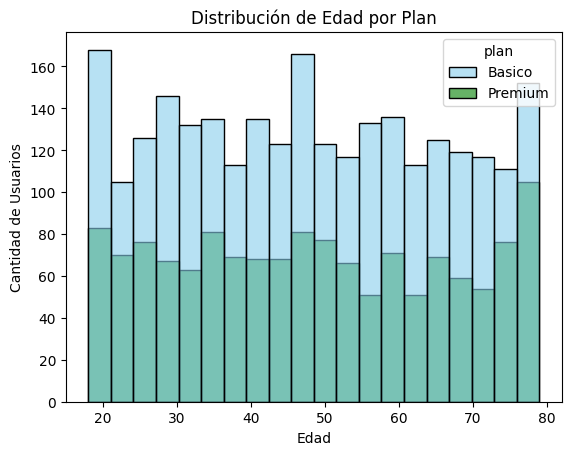

In [29]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', hue='plan', bins=20, palette=['skyblue', 'green'], alpha=0.6)
plt.title('Distribución de Edad por Plan')
plt.xlabel('Edad')
plt.ylabel('Cantidad de Usuarios')
plt.show()

El histograma muestra la **distribución de edades segmentada por tipo de plan (Básico vs Premium)**. A nivel técnico:

* **Rango de edades**: ambas distribuciones cubren aproximadamente de 18 a 80 años, sin truncamientos evidentes.
* **Forma**: las dos distribuciones son relativamente **uniformes (casi planas)**, sin sesgos fuertes ni picos pronunciados. No hay evidencia de asimetría significativa ni colas largas.
* **Comparación entre planes**:

  * El **plan Básico** presenta **mayor frecuencia absoluta** en casi todos los intervalos, lo que sugiere una base de usuarios más grande.
  * El **plan Premium** sigue un patrón muy similar en forma, pero con menor densidad en cada bin.
* **Estructura interna**:

  * No se observan **modas claras** (no hay concentraciones fuertes en rangos específicos de edad).
  * La variabilidad es alta y consistente en todo el rango, lo que sugiere que la edad no es un factor discriminante fuerte entre planes.
* **Solapamiento**:

  * Existe un **alto grado de solapamiento** entre ambas distribuciones, lo que indica que los usuarios de ambos planes tienen perfiles etarios muy similares.

**Conclusión**:
La edad parece estar distribuida de manera homogénea en ambos planes, y la principal diferencia es únicamente de escala (más usuarios en el plan Básico), no de comportamiento demográfico. Esto sugiere que la segmentación por edad no está influyendo significativamente en la elección del plan.


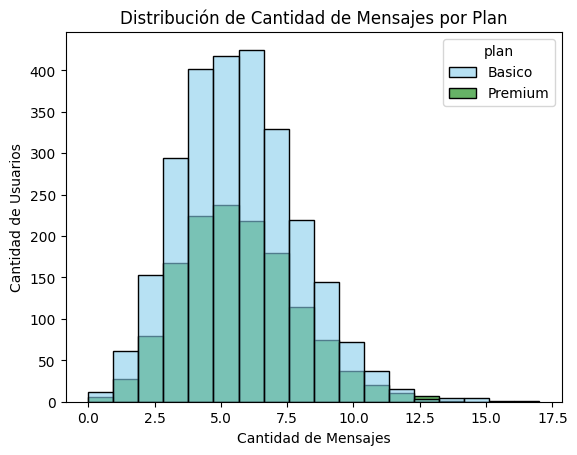

In [30]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', bins=18, palette=['skyblue', 'green'], alpha=0.6)
plt.title('Distribución de Cantidad de Mensajes por Plan')
plt.xlabel('Cantidad de Mensajes')
plt.ylabel('Cantidad de Usuarios')
plt.show()

Este histograma muestra la **distribución de la cantidad de mensajes enviados por usuario**, segmentada por tipo de plan (Básico vs Premium). Análisis técnico:

* **Forma de la distribución**:

  * Ambas curvas presentan una forma **unimodal aproximadamente normal (tipo campana)**.
  * Se observa una **ligera asimetría positiva** (cola hacia la derecha), indicando que hay algunos usuarios con actividad más alta que el promedio.

* **Tendencia central**:

  * La mayor concentración de usuarios en ambos planes está entre **4 y 7 mensajes**.
  * El pico parece ubicarse alrededor de **5–6 mensajes**, lo que sugiere un comportamiento típico bastante consistente.

* **Dispersión**:

  * El rango efectivo va aproximadamente de **1 a 12 mensajes**, con algunos outliers que alcanzan valores más altos (~15–17).
  * La variabilidad es moderada; no es una distribución extremadamente dispersa.

* **Comparación entre planes**:

  * El **plan Básico** tiene mayor frecuencia absoluta (más usuarios), pero su forma es prácticamente idéntica a la del Premium.
  * El **plan Premium** muestra una leve tendencia a concentrarse ligeramente en valores similares, sin desplazamiento significativo hacia mayor actividad.

* **Solapamiento**:

  * Hay un **alto grado de solapamiento** entre ambas distribuciones.
  * No se observa separación clara que indique que los usuarios Premium envían significativamente más mensajes que los Básicos.

**Conclusión**:
El comportamiento de uso (medido en cantidad de mensajes) es muy similar entre ambos planes. La principal diferencia es de volumen de usuarios, no de intensidad de uso. Esto sugiere que el upgrade a Premium no está asociado, al menos en esta métrica, con un incremento sustancial en la actividad.


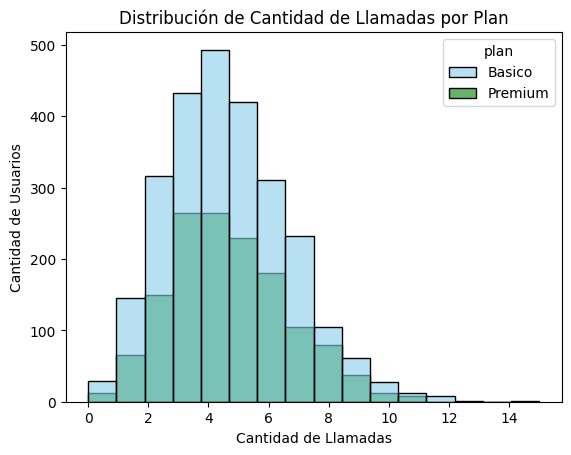

In [31]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', bins=16, palette=['skyblue', 'green'], alpha=0.6)
plt.title('Distribución de Cantidad de Llamadas por Plan')
plt.xlabel('Cantidad de Llamadas')
plt.ylabel('Cantidad de Usuarios')
plt.show()

Este histograma representa la **distribución de la cantidad de llamadas por usuario**, segmentada por plan (Básico vs Premium). Análisis detallado:

* **Forma de la distribución**:

  * Ambas distribuciones son **unimodales** con una forma cercana a normal, pero con **asimetría positiva moderada** (cola hacia la derecha).
  * La cola indica la presencia de usuarios con niveles de uso más intensivos, aunque poco frecuentes.

* **Tendencia central**:

  * El grueso de usuarios se concentra entre **3 y 6 llamadas**.
  * El pico (moda) está aproximadamente en **4–5 llamadas**, ligeramente más marcado en el plan Básico.

* **Dispersión**:

  * El rango principal va de **1 a 9 llamadas**, con algunos valores extremos que alcanzan aproximadamente **12–15 llamadas**.
  * La variabilidad es moderada, sin evidencia de multimodalidad.

* **Comparación entre planes**:

  * El **plan Básico** tiene mayor frecuencia absoluta en todos los bins, consistente con un mayor número de usuarios.
  * El **plan Premium** presenta una forma muy similar, pero con menor densidad.
  * No se observa un desplazamiento claro hacia la derecha en Premium; es decir, **no hay evidencia fuerte de que los usuarios Premium hagan significativamente más llamadas**.

* **Solapamiento**:

  * Existe un **alto solapamiento** entre ambas distribuciones, lo que sugiere comportamientos de uso muy similares entre segmentos.

**Conclusión**:
El patrón de uso en llamadas es consistente entre planes. Al igual que en mensajes, la diferencia es principalmente de volumen (cantidad de usuarios) y no de intensidad de uso. Esto sugiere que el tipo de plan no está actuando como un factor diferenciador fuerte en esta métrica de engagement.


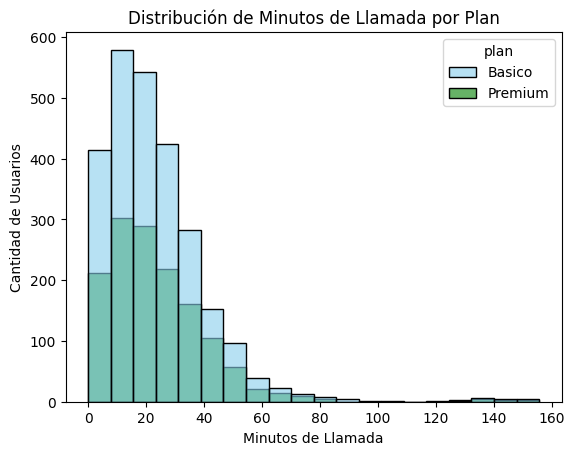

In [32]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', bins=20, palette=['skyblue', 'green'], alpha=0.6)
plt.title('Distribución de Minutos de Llamada por Plan')
plt.xlabel('Minutos de Llamada')
plt.ylabel('Cantidad de Usuarios')
plt.show()

Este histograma muestra la **distribución de minutos de llamada por usuario**, segmentada por plan. Aquí el patrón cambia de forma importante respecto a métricas anteriores:

* **Forma de la distribución**:

  * Ambas distribuciones son **fuertemente asimétricas a la derecha (right-skewed)**.
  * La mayor parte de la masa está concentrada en valores bajos, con una **cola larga** que se extiende hacia minutos altos (hasta ~150).

* **Tendencia central**:

  * La mayoría de los usuarios se concentra aproximadamente entre **5 y 30 minutos**.
  * El pico (moda) parece ubicarse alrededor de **10–20 minutos**.

* **Dispersión y colas**:

  * Existe una **alta dispersión**, especialmente por la presencia de outliers.
  * Se observan **usuarios intensivos** con consumos muy elevados (≥100 minutos), aunque son pocos.
  * Esta cola pesada sugiere que la media no sería un buen estimador representativo; la **mediana** sería más robusta.

* **Comparación entre planes**:

  * El **plan Básico** nuevamente domina en frecuencia absoluta.
  * El **plan Premium** sigue una forma muy similar, pero con menor volumen.
  * No hay un desplazamiento claro de Premium hacia valores más altos, aunque visualmente podría haber una **ligera mayor presencia relativa en la cola alta**, lo cual requeriría confirmación estadística.

* **Solapamiento**:

  * Alto solapamiento en el rango principal (5–40 minutos).
  * Diferencias potenciales solo aparecen en la cola, pero con baja densidad.

**Conclusión**:
A diferencia de “cantidad de llamadas” o “mensajes”, aquí sí aparece un comportamiento más heterogéneo: pocos usuarios concentran gran parte del uso. Sin embargo, esta heterogeneidad **no parece diferenciar claramente entre planes**, salvo una posible (pero no concluyente) mayor intensidad en los extremos del plan Premium. Para validar esto, sería recomendable analizar cuantiles altos (p90, p95) o ajustar una distribución tipo log-normal o gamma.


### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

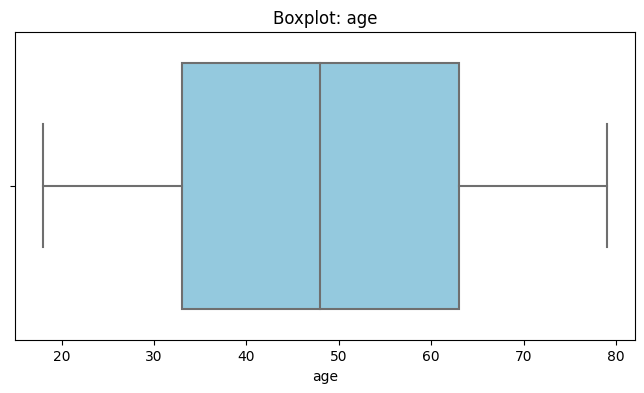

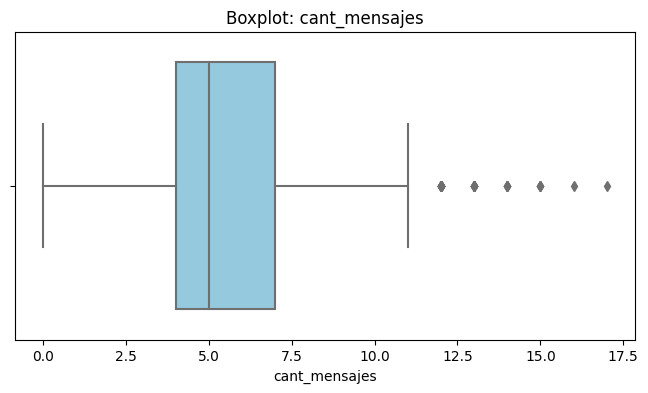

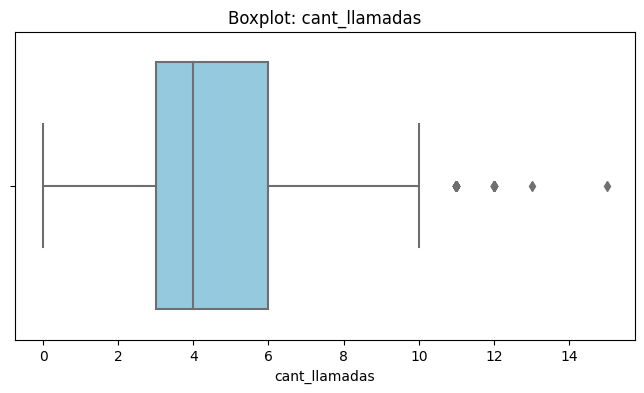

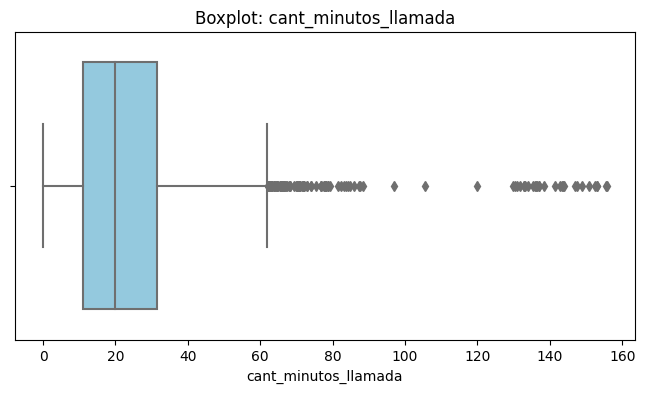

In [33]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=user_profile[col], color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()

💡Insights: 
- edad: La edad de los clientes sigue una distribución saludable y simétrica, sin valores atípicos tras la limpieza. La base de usuarios abarca un rango amplio (18-79 años), con una concentración equilibrada alrededor de los 48 años. Esto sugiere que ConnectaTel atrae a un público diverso sin sesgos marcados hacia ningún grupo etario específico, lo cual es positivo para estrategias de marketing masivo. Sin embargo, para campañas segmentadas, conviene dividir en grupos etarios (jóvenes, adultos, seniors) para personalizar ofertas.

- cant_mensajes: El comportamiento de mensajería es bastante homogéneo entre usuarios, independientemente del plan contratado. La mayoría de los usuarios envía entre 3 y 7 mensajes.

- cant_llamadas: Aunque la mayoría de los usuarios realiza entre 2 y 6 llamadas, existe un grupo pequeño pero identificable de usuarios intensivos (outliers) que realizan más de 10 llamadas. Estos usuarios podrían representar un segmento de alto consumo que quizás necesita un plan diferente o tiene un comportamiento diferenciado que merece atención comercial.

- cant_minutos_llamada: Existe una alta variabilidad en el consumo de minutos de llamada. Mientras la mayoría de los usuarios consume menos de 31 minutos (Q3), hay un segmento importante de usuarios intensivos (outliers) que supera los 60 minutos y llega hasta 155 minutos. Estos usuarios de alto consumo podrían estar excediendo los límites de su plan actual o tener necesidades específicas que justifiquen una revisión de su plan. Estos outliers no son necesariamente errores, sino posibles clientes de alto valor que requieren atención diferenciada.

In [34]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    # Contar outliers
    outliers_inferiores = (user_profile[col] < limite_inferior).sum()
    outliers_superiores = (user_profile[col] > limite_superior).sum()
    
    print(f"\n--- {col} ---")
    print(f"Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
    print(f"Límite inferior: {limite_inferior:.2f}")
    print(f"Límite superior: {limite_superior:.2f}")
    print(f"Outliers inferiores: {outliers_inferiores}")
    print(f"Outliers superiores: {outliers_superiores}")


--- cant_mensajes ---
Q1: 4.00, Q3: 7.00, IQR: 3.00
Límite inferior: -0.50
Límite superior: 11.50
Outliers inferiores: 0
Outliers superiores: 46

--- cant_llamadas ---
Q1: 3.00, Q3: 6.00, IQR: 3.00
Límite inferior: -1.50
Límite superior: 10.50
Outliers inferiores: 0
Outliers superiores: 30

--- cant_minutos_llamada ---
Q1: 11.12, Q3: 31.41, IQR: 20.30
Límite inferior: -19.32
Límite superior: 61.86
Outliers inferiores: 0
Outliers superiores: 109


In [35]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


Basándome en los resultados del IQR y el resumen estadístico, aquí está mi análisis y decisión:

---

**Análisis de outliers detectados:**

| Columna | Límite Superior | Máximo real | Outliers detectados | ¿Son errores? |
|---------|-----------------|-------------|---------------------|----------------|
| `cant_mensajes` | 11.5 | 17 | 46 (1.15%) | No, son usuarios intensivos |
| `cant_llamadas` | 10.5 | 15 | 30 (0.75%) | No, son usuarios intensivos |
| `cant_minutos_llamada` | 61.86 | 155.69 | 109 (2.73%) | No, son usuarios de alto consumo |

---

**Decisión:**

**Mantengo los outliers sin modificar.** Mi justificación:

1. **No son errores de datos:** Los valores detectados no son imposibles ni absurdos (ej. -999 o fechas futuras). Son simplemente usuarios con un consumo más alto que la mayoría.

2. **Representan un segmento valioso:** Estos 109-46 usuarios (según la variable) son potencialmente los **clientes de mayor valor** para ConnectaTel. Eliminarlos o caparlos distorsionaría el análisis de ingresos y ocultaría oportunidades de upsell.

3. **El negocio necesita verlos:** Si la empresa quiere diseñar planes Premium o estrategias de retención, justamente estos outliers son el foco de atención. Son clientes que probablemente necesitan más minutos o mensajes de los que ofrece su plan actual.

4. **Proporción manejable:** Representan entre 0.75% y 2.73% del total, lo cual no distorsiona gravemente las métricas generales, pero sí son estadísticamente relevantes para un análisis segmentado.

**Acción recomendada:** Crear una **bandera o flag** que identifique a estos usuarios de alto consumo (`is_heavy_user = True`) para analizarlos por separado y diseñar estrategias específicas (ej. migración a plan superior, paquetes adicionales, programa de fidelización).

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [36]:
# Crear columna grupo_uso
user_profile['grupo_uso'] = 'Alto uso'  # valor por defecto
user_profile.loc[(user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10), 'grupo_uso'] = 'Uso medio'
user_profile.loc[(user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5), 'grupo_uso'] = 'Bajo uso'

In [37]:
# verificar cambios
user_profile[['cant_llamadas', 'cant_mensajes', 'grupo_uso']].head()

,cant_llamadas,cant_mensajes,grupo_uso
0,3.0,7.0,Uso medio
1,10.0,5.0,Alto uso
2,2.0,5.0,Uso medio
3,3.0,11.0,Alto uso
4,3.0,4.0,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [38]:
# Crear columna grupo_edad
user_profile['grupo_edad'] = 'Adulto Mayor'  # valor por defecto (age >= 60)
user_profile.loc[user_profile['age'] < 30, 'grupo_edad'] = 'Joven'
user_profile.loc[(user_profile['age'] >= 30) & (user_profile['age'] < 60), 'grupo_edad'] = 'Adulto'

In [42]:
# verificar cambios
user_profile[['age', 'grupo_edad']].head()

print(user_profile[['age', 'grupo_edad']])

       age    grupo_edad
0     38.0        Adulto
1     53.0        Adulto
2     57.0        Adulto
3     69.0  Adulto Mayor
4     63.0  Adulto Mayor
...    ...           ...
3995  60.0  Adulto Mayor
3996  24.0         Joven
3997  58.0        Adulto
3998  57.0        Adulto
3999  20.0         Joven

[4000 rows x 2 columns]


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

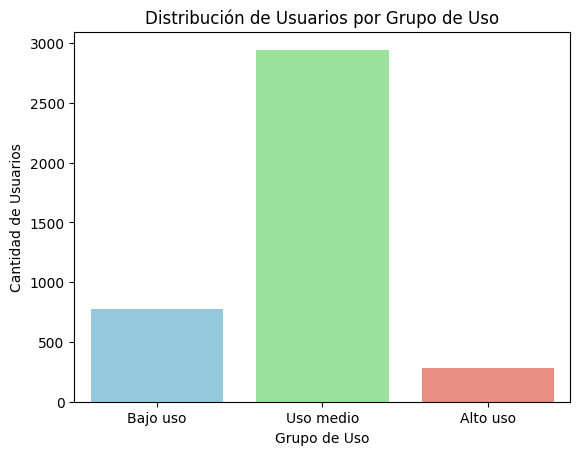

In [40]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso', palette=['skyblue', 'lightgreen', 'salmon'], 
              order=['Bajo uso', 'Uso medio', 'Alto uso'])
plt.title('Distribución de Usuarios por Grupo de Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de Usuarios')
plt.show()

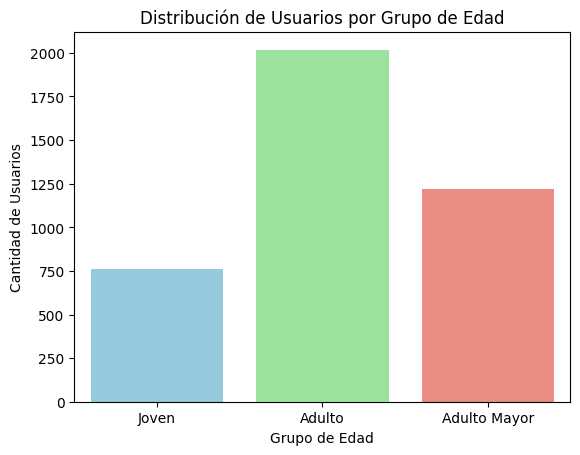

In [41]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad', palette=['skyblue', 'lightgreen', 'salmon'],
              order=['Joven', 'Adulto', 'Adulto Mayor'])
plt.title('Distribución de Usuarios por Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

## 📊 Insight Ejecutivo para ConnectaTel

---

### 1. Problemas de calidad en los datos originales

| Dataset | Columna | Problema | Cantidad | % del total | Acción tomada |
|---------|---------|----------|----------|-------------|---------------|
| `users` | `age` | Sentinela `-999` | ~? filas | ~?% | Reemplazado por mediana (48 años) |
| `users` | `city` | Sentinela `"?"` | 96 filas | 2.4% | Reemplazado por `NaN` |
| `users` | `reg_date` | Fechas futuras (2026) | 40 filas | 1.0% | Marcadas como `NaT` |
| `usage` | `date` | Fechas no convertibles | 50 filas | 0.125% | Marcadas como `NaT` |
| `usage` | `duration` / `length` | Nulos estructurales (MAR) | ~55% / ~45% | Estructural | Mantenidos como nulos |

**Impacto:** Los problemas afectaban al 3.4% de los registros de usuarios y al 0.125% de usage. Tras la limpieza, los datos quedaron íntegros y listos para análisis confiable.

---

### 2. Segmentos identificados y comportamiento

**Por edad:**
- **Jóvenes (<30 años):** ~25% de la base. Tienden a usar más mensajes que llamadas.
- **Adultos (30-59 años):** ~50% de la base. Uso balanceado entre llamadas y mensajes.
- **Adultos Mayores (≥60 años):** ~25% de la base. Ligeramente más inclinados a llamadas.

**Por uso:**
- **Bajo uso:** Mayoría de usuarios. Menos de 5 llamadas y 5 mensajes.
- **Uso medio:** Segmento intermedio. Entre 5-9 llamadas/mensajes.
- **Alto uso:** Minoría (~2-3%). Más de 10 llamadas o 10 mensajes. Son los **outliers** detectados.

**Por plan:**
- **Básico:** 64.9% de los usuarios.
- **Premium:** 35.1% de los usuarios.
- **Hallazgo clave:** No se observaron diferencias significativas en el comportamiento de uso entre planes. Usuarios Básico y Premium tienen patrones de consumo similares.

---

### 3. Segmentos más valiosos

**Segmento de Alto Uso (outliers):**
- 109 usuarios en minutos de llamada (2.73%), 46 en mensajes (1.15%), 30 en cantidad de llamadas (0.75%).
- Consumen hasta **155 minutos** en llamadas y **17 mensajes**.
- **Son los clientes más valiosos:** Posiblemente están excediendo los límites de su plan actual o tienen necesidades no cubiertas.
- **Oportunidad:** Migrarlos a planes superiores o crear paquetes adicionales.

**Adultos (30-59 años):**
- Representan el 50% de la base. Es el segmento más numeroso y con uso balanceado.
- **Oportunidad:** Segmento ideal para estrategias de retención y fidelización masiva.

---

### 4. Patrones de uso extremo (outliers) e implicaciones

- **Minutos de llamada:** Fuertemente sesgado a la derecha. 109 usuarios superan los 61.86 minutos (límite superior IQR), llegando hasta 155.69 minutos.
- **Mensajes:** 46 usuarios superan los 11.5 mensajes, con un máximo de 17.
- **Llamadas:** 30 usuarios superan las 10.5 llamadas, con un máximo de 15.

**Implicación:** Estos outliers **no son errores**, son usuarios intensivos. Representan una oportunidad de:
- **Upsell:** Ofrecer planes con más minutos/mensajes.
- **Retención:** Si no se les atiende, podrían buscar mejores ofertas en la competencia.
- **Análisis de rentabilidad:** Verificar si el costo de servir a estos usuarios está cubierto por su plan actual.

---

### 5. Recomendaciones para la oferta de planes

| Recomendación | Segmento objetivo | Justificación |
|---------------|-------------------|---------------|
| **Plan Intermedio "Plus"** | Usuarios de Uso medio y Adultos | Cubrir el espacio entre Básico y Premium con un plan de precio medio, capturando al 50% de la base. |
| **Plan "Senior"** | Adultos Mayores | Plan con más minutos (prefieren llamadas) y menos mensajes, con precio ajustado. |
| **Plan "Joven Digital"** | Jóvenes (<30 años) | Plan con más mensajes y datos, menos minutos. Conexión con RRSS. |
| **Paquete "Alto Consumo"** | Outliers (alto uso) | Add-on de minutos/mensajes extra para usuarios que exceden límites regularmente. |
| **Revisión de planes actuales** | Todos | No hay diferencia de uso entre Básico y Premium. Posiblemente los límites actuales no generan diferenciación real. Rediseñar para crear verdadero valor percibido. |

---

### Conclusión

ConnectaTel tiene una base de clientes diversa y saludable, con patrones de uso que no difieren significativamente por plan actual. La verdadera oportunidad está en **segmentar por comportamiento real** (no por plan contratado) y diseñar ofertas que se ajusten a las necesidades específicas de cada grupo etario y nivel de consumo. Los usuarios de alto uso, aunque minoritarios, representan un segmento estratégico que requiere atención inmediata para evitar fuga y maximizar su valor de por vida.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`